# Automatically Defined Functions

This notebook introduces Automatically Defined Functions (ADFs) in TurboGP. ADFs are a way to incorporate modular architetures in GP. The ADF framework consists in evolving GP models with more than one tree, in an architecture that mimics a "main function-subroutines" paradigm of coding. Each individual is comprised of one tree that performs the role of a "main function", i.e. the default tree that is evaluated to perform a prediction, and a set of additional trees that work as subroutines. The set of primitives available to main trees evolution consists of not only the standard basic functions, but also special primitives that represent the additional trees. This way, not only the main tree is evolved, but also primitives the main function can make use of.

For more information and a complete reference and understanding of the ADF framework, refer to Koza's book "Genetic Programming II".

## Introduction to ADFs

In this notebook we will only show the basic mechanisms behind ADFs creation and operation. There is another notebook with a complete run using ADFs for a regression problem.

First, as usual, we will declare the basic libraries we will need for this demo.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from networkx.drawing.nx_agraph import graphviz_layout

These other are the GP libraries we'll need,

In [2]:
from GPIndividuals import *      # where core classes (node, tree) are defined
from GPOperators import *        # where basic crossover and mutation are defined

from LowLevel import *           # where low-level primitives are defined

from GPUtils import *            # Selection (binary tournament, roulette wheel, elite selection) and migration methods
from Utils import *              # other optional functions

Now, let's define the set of basic primitives available to all trees we will generate

In [3]:
lowlevel = ['ADD', 'SUB', 'MUL']
Node.f1_set=lowlevel
Node.i2_set=[-1.0,1.0]

We can now create a tree that will serve as the subroutine.

In [4]:
# Create a new object of the class tree, specifiying the max allowed depth, and the set of input feature variables:
adf1 = Tree(max_tree_depth=3, i1_set=np.arange(2))
# Generate the tree
adf1.grow_random_tree()

Let's visualize it

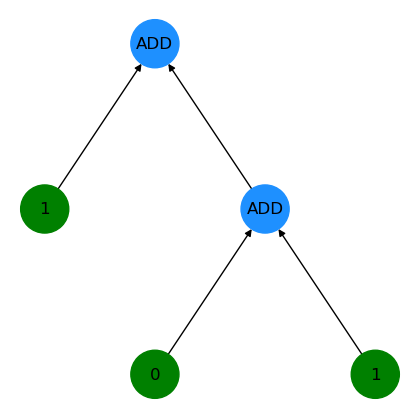

In [5]:
plt.figure(figsize=(4,4))
graph, labels, color_map = get_graph(adf1)
nx.draw(graph, pos=nx.nx_agraph.graphviz_layout(graph.reverse(), prog="dot"), with_labels=True, labels=labels, node_size=1200, node_color=color_map)

The above tree represents the function $adf(x_0, x_1) = x_1 + (x_0 + x_1)$

If you are wondering why the ADF used two variables, notice above how when we created the adf1 tree we specified i1_set to be of size 2.

Now, let's create a tree that serves as the "main function", a tree that can make calls to the subroutine we just created.

In [90]:
# Create a new object of the class tree, specifiying the max allowed depth, and the set of input feature variables:
main = Tree(max_tree_depth=3, i1_set=np.arange(2))
# Include 'adf1' in the primitives set of main tree, so it can appear in the tree structure
main.update_f4_set([adf1])
# Generate the tree
main.grow_random_tree()

Let's visualize it

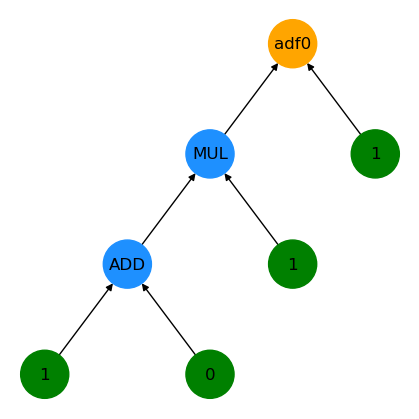

In [91]:
plt.figure(figsize=(4,4))
graph, labels, color_map = get_graph(main)
nx.draw(graph, pos=nx.nx_agraph.graphviz_layout(graph.reverse(), prog="dot"), with_labels=True, labels=labels, node_size=1200, node_color=color_map)

We had to run the above lines several times, in order to get a neat main function for this demo, and because sometimes the generated trees did not include the ADF in its nodes.

__The probability of picking an ADF as a node is established in the class `node` in GPIndividuals.py module as the member variable `prob_f1f4` currently set to (.9, .1) regular primitive/adf.__

The function represented by the main function is $adf((x_1 + x_0)*x_1, x_1)$

If we expand it considering the function represented by the ADF, we got: $x_1 + (((x_1 + x_0)*x_1) + x_1)$

In this case, the expansion was easy (albeit confusing) because the second variable $x_1$ of the main tree is used as the second variable $x_1$ of the subroutine, so we only had to replace $x_0$ in the adf with the corresponding branch of the main tree.


Now, let's evaluate the ADF individually...

In [92]:
adf1.evaluate([2,3])

8

We can see the results adds up. Now, the main tree...

In [93]:
main.evaluate([2,3])

21

We can see the the result is also correct. We have created our first GP model with ADFs!

---

## Genetic Operations with ADFs

The above examples showed how to create GP trees for main functions and ADF subroutines from scratch. But TurboGP also includes class that implements a GP individual for scalar regression using ADFs. This individual already comes with the standard set of GP operations such as mutation and different crossovers.

Let's create on of these individuals. First, we need to import the module that specifies it.

In [94]:
from ADFRegressor import Regressor1ADF 

We can now create one of this individuals,

In [95]:
original = Regressor1ADF(input_vector_size = 2, 
                         adf_arity =2, 
                         complexity = 3, 
                         adf_complexity = 3)

Let's plot its __main__ tree:

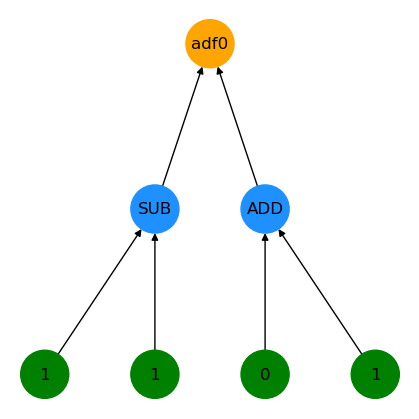

In [97]:
plt.figure(figsize=(4,4))
graph, labels, color_map = get_graph(original.trees[0]) # notice it is the first tree
nx.draw(graph, pos=nx.nx_agraph.graphviz_layout(graph.reverse(), prog="dot"), with_labels=True, labels=labels, node_size=1200, node_color=color_map)

Let's plot its subroutine:

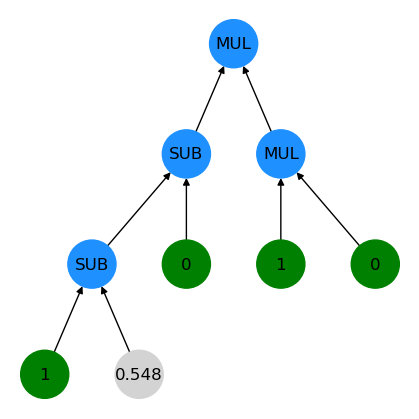

In [98]:
plt.figure(figsize=(4,4))
graph, labels, color_map = get_graph(original.trees[1]) # notice it is the second tree 
nx.draw(graph, pos=nx.nx_agraph.graphviz_layout(graph.reverse(), prog="dot"), with_labels=True, labels=labels, node_size=1200, node_color=color_map)

This turned out to be a bad example because if we put attention, we'll notice the result of this composite model will always yield zero. Let's try it

In [99]:
original.predict([2,3])

0.0

Still, the math checks out. So, now let's try the genetic operations.

Note that, unlike the manual example performed earlier, in this case we did not had to create the main tree several times to include an ADF: the ADFRegressor class already ensures the ADF appears as a node in the main function at least once.

It is also important to remark that, while the ADF specification considers GP models with several ADFs and hierachies (ADFs that can all other ADFs), here the ADFRegressor module only implementates an individual with a single ADF; but it shouldn't be difficult to extend it to support more than one ADF in the first layer.

## Mutation

In the ADF framework, the genetic operations are performed as if everything is a giantic tree, but taking into consideration the context of the point where the crossover or mutation will take place.

This means that ADF1 will only crossover with ADF1, ADF2 will only crossover with ADF2, main function will only crossover with main functions, and so on. Similarly, for mutation, a random modification of an ADF branch will only modify the ADF itself, and not affect the rest of the trees.

This also means there is only a single operation carried per individual per generation, i.e. no breeding individuals by crossing more than one ADF and/or main functions (that would mean two genetic operations).

Ultimately, this means that when we perform a genetic operation, one of the different modules (incl. the main function) is picked at random, and the OP is performed as usual, but module wise.

Let's see what happens with the mutation.

In [109]:
clone1 = Regressor1ADF.mutation(original)

Let's visualize both the main tree and the ADF to see which one of the two changed,

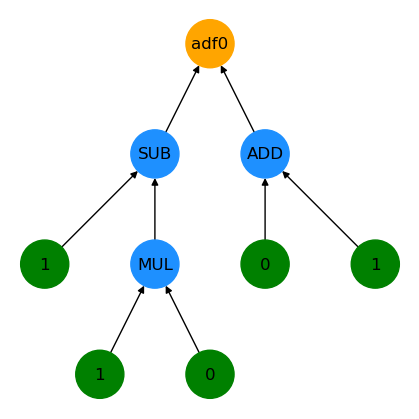

In [110]:
plt.figure(figsize=(4,4))
graph, labels, color_map = get_graph(clone1.trees[0])
nx.draw(graph, pos=nx.nx_agraph.graphviz_layout(graph.reverse(), prog="dot"), with_labels=True, labels=labels, node_size=1200, node_color=color_map)

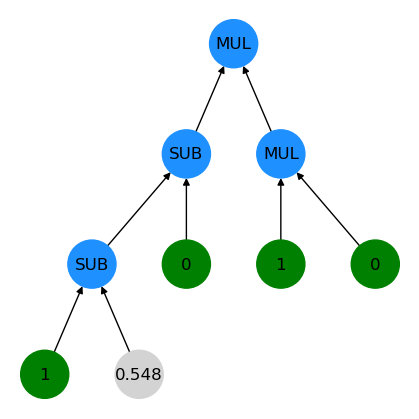

In [111]:
plt.figure(figsize=(4,4))
graph, labels, color_map = get_graph(clone1.trees[1])
nx.draw(graph, pos=nx.nx_agraph.graphviz_layout(graph.reverse(), prog="dot"), with_labels=True, labels=labels, node_size=1200, node_color=color_map)

As we can see, the main function is the one that has changed in the offspring. And if we evaluate the new model, we can confirm the behavioral change as well

In [112]:
clone1.predict([2,3])

21.773980101594262

But it could have been the ADF module the one that mutated. We can perform another mutation to confirm this. 

In [119]:
clone2 = Regressor1ADF.mutation(original)

Let's visualize both the main tree and the ADF to see which one of the two changed,

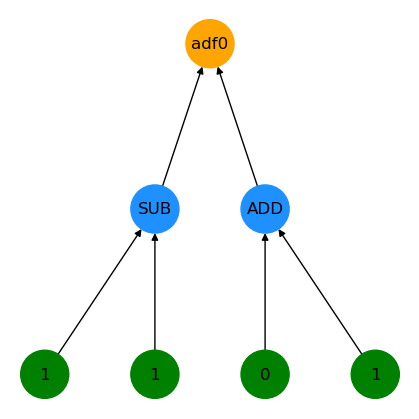

In [120]:
plt.figure(figsize=(4,4))
graph, labels, color_map = get_graph(clone2.trees[0])
nx.draw(graph, pos=nx.nx_agraph.graphviz_layout(graph.reverse(), prog="dot"), with_labels=True, labels=labels, node_size=1200, node_color=color_map)

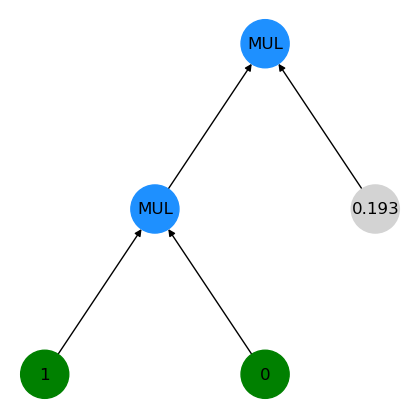

In [121]:
plt.figure(figsize=(4,4))
graph, labels, color_map = get_graph(clone2.trees[1])
nx.draw(graph, pos=nx.nx_agraph.graphviz_layout(graph.reverse(), prog="dot"), with_labels=True, labels=labels, node_size=1200, node_color=color_map)

(we may had to perform the mutation several times; remember that the operation point is chosen at random)

In this case, now it is the ADF that changed. 



## Crossover

...

---

## Node and node type count

To determine if an ADF equipped GP is better than a standard GP, it is necessary to compare the performance of both (error or accuracy measures) under a computational cost basis. That is, what is the real cost of evolving a population vs the other?

To do so, we can determine the cost of evaluating a single individual by calculating the number of "node evaluations" it requires. This means, counting the number of nodes in all trees that comprise it, and multiplicating the number of ADF nodes in the main function by the number of nodes in each corresponding ADF tree. 

TurboGP tree class now includes the necessary functions to perform this count. Let's see it.

In [136]:
maintree_node_count = clone2.trees[0].count_nodes_type()

The above function returns a dictionary with the node count per type, including the total sum considering all types:

In [137]:
maintree_node_count['f4'] #ADF nodes

1

In [138]:
maintree_node_count['i1'] # leaf variable nodes

4

In [139]:
maintree_node_count['total']

7

And for the ADF,

In [140]:
adf_node_count = clone2.trees[1].count_nodes_type()

In [141]:
adf_node_count['f4'] #ADF nodes

0

In [142]:
adf_node_count['i1'] # leaf variable nodes

2

In [143]:
adf_node_count['i2'] # leaf constant nodes

1

In [144]:
adf_node_count['total']

5

What is the total cost of of evaluating clone2? it is the the total number of nodes in the main function plus the product of the ADF nodes in the main function times the total number of nodes in the ADF:

In [145]:
maintree_node_count['total'] + maintree_node_count['f4']*adf_node_count['total']

12